# Measured silica-polymerization kinetics validation

This notebook evaluates normalized fourth-order decay against the measured Silica Polymerization Experimental Data workbook. Each experiment is split by time into 60% fitting, 20% interval calibration, and 20% late-time testing.

This is within-experiment time-extrapolation evidence. It does not validate a universal mechanism, cross-condition prediction, reactor scale-up, heat release, transport, or process safety.

In [1]:
from pathlib import Path
import os,sys,json
import pandas as pd
import matplotlib.pyplot as plt
repo=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd(); sys.path.insert(0,str(repo/'src'))
from chemical_reactor_twin.measured_validation import run_silica_validation
candidate=Path(os.environ.get('REACTOR_TWIN_SILICA_DATA',repo/'datasets/external/SupplementaryData_SilicaPolymerization.xlsx'))
if not candidate.exists(): candidate=(repo/'../SupplementaryData_SilicaPolymerization.xlsx').resolve()
print('Repository:',repo.resolve()); print('Dataset:',candidate); print('Dataset exists:',candidate.exists())

Repository: /root/sessions/481_repository-analysis-inquiry/origin_reactor
Dataset: /root/sessions/481_repository-analysis-inquiry/SupplementaryData_SilicaPolymerization.xlsx
Dataset exists: True


In [2]:
summary=run_silica_validation(candidate,repo/'outputs/measured_silica'); a=summary['aggregate']; print('Scientific status:',summary['scientific_status']); print('Experiments:',a['experiments']); print(f"Median fourth-order RMSE: {a['median_fourth_order_rmse_normalized']:.4f}"); print(f"Median first-order RMSE: {a['median_first_order_rmse_normalized']:.4f}"); print(f"Fourth-order better: {a['fourth_order_better_count']}/{a['experiments']}"); print(f"Median fourth-order R2: {a['median_fourth_order_r2']:.4f}"); print(f"Median empirical 90% interval coverage: {a['median_interval_coverage']:.4f}")

Scientific status: Measured-data Level 1 evidence for within-experiment silica polymerization time extrapolation
Experiments: 61
Median fourth-order RMSE: 0.1710
Median first-order RMSE: 0.3077
Fourth-order better: 51/61
Median fourth-order R2: -48.8337
Median empirical 90% interval coverage: 0.1000


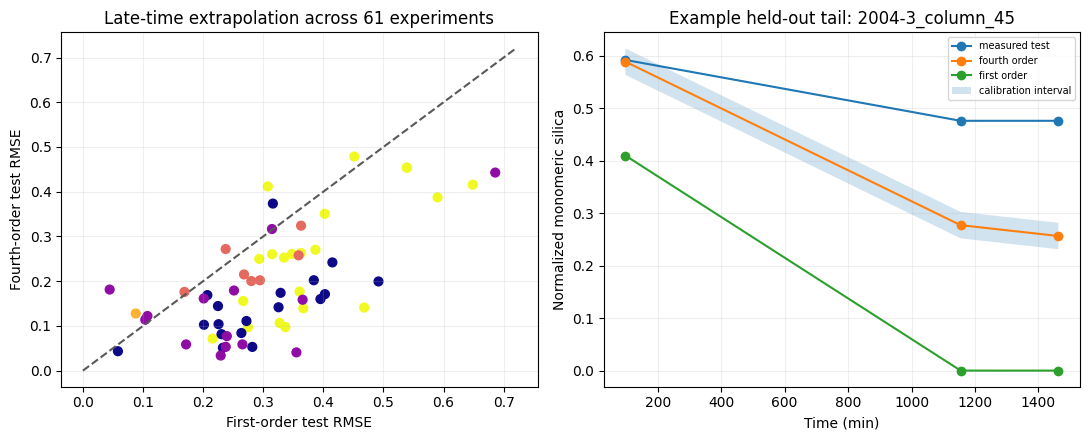

In [3]:
m=pd.read_csv(repo/'outputs/measured_silica/per_experiment_metrics.csv'); p=pd.read_csv(repo/'outputs/measured_silica/test_predictions.csv'); fig,axs=plt.subplots(1,2,figsize=(11,4.5)); axs[0].scatter(m.baseline_rmse_normalized,m.model_rmse_normalized,c=m.temperature_c,cmap='plasma',s=40); lim=max(m.baseline_rmse_normalized.max(),m.model_rmse_normalized.max())*1.05; axs[0].plot([0,lim],[0,lim],'--',color='.35'); axs[0].set(xlabel='First-order test RMSE',ylabel='Fourth-order test RMSE',title='Late-time extrapolation across 61 experiments'); axs[0].grid(alpha=.2); eid=m.sort_values('model_rmse_normalized').experiment_id.iloc[len(m)//2]; q=p[p.experiment_id==eid].sort_values('time_min'); axs[1].plot(q.time_min,q.normalized_silica,'o-',label='measured test'); axs[1].plot(q.time_min,q.fourth_order_prediction,'o-',label='fourth order'); axs[1].plot(q.time_min,q.first_order_baseline,'o-',label='first order'); axs[1].fill_between(q.time_min,q.lower_90,q.upper_90,alpha=.2,label='calibration interval'); axs[1].set(xlabel='Time (min)',ylabel='Normalized monomeric silica',title=f'Example held-out tail: {eid}'); axs[1].legend(fontsize=7); axs[1].grid(alpha=.2); plt.tight_layout(); plt.show()

In [4]:
print('Median RMSE improvement (%):',round(100*(a['median_first_order_rmse_normalized']-a['median_fourth_order_rmse_normalized'])/a['median_first_order_rmse_normalized'],2)); print('Coverage range:',round(m.interval_coverage.min(),3),'to',round(m.interval_coverage.max(),3)); print('Interpretation: fourth-order decay improves the median late-time error, but interval coverage collapses under temporal extrapolation. This is evidence of model-form drift and prevents a robust predictive claim.')

Median RMSE improvement (%): 44.42
Coverage range: 0.0 to 1.0
Interpretation: fourth-order decay improves the median late-time error, but interval coverage collapses under temporal extrapolation. This is evidence of model-form drift and prevents a robust predictive claim.
